In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Carregar dataset corretamente (o separador original da UCI é ponto e vírgula)
df = pd.read_csv("winequality-white.csv", sep=";")

# 2. Mostrar shape
print("Shape do dataset original:", df.shape)

# 3 e 4. Listar colunas, dtypes e contar valores ausentes
info_df = pd.DataFrame({
    'Tipo de Dado': df.dtypes,
    'Valores Ausentes': df.isnull().sum()
})
print("\n--- Estrutura e Dados Ausentes ---")
print(info_df)

# 5. Contar duplicatas
print("\nDuplicatas exatas encontradas:", df.duplicated().sum())

Shape do dataset original: (4898, 12)

--- Estrutura e Dados Ausentes ---
                     Tipo de Dado  Valores Ausentes
fixed acidity             float64                 0
volatile acidity          float64                 0
citric acid               float64                 0
residual sugar            float64                 0
chlorides                 float64                 0
free sulfur dioxide       float64                 0
total sulfur dioxide      float64                 0
density                   float64                 0
pH                        float64                 0
sulphates                 float64                 0
alcohol                   float64                 0
quality                     int64                 0

Duplicatas exatas encontradas: 937


In [7]:
# 6 e 7. Describe() completo mostrando min, max, mean, 50% (mediana) e std
print("--- Estatísticas Descritivas ---")
estatisticas = df.describe().T[['min', 'max', 'mean', '50%', 'std']]
print(estatisticas)

# 8. Distribuição absoluta e percentual de quality
print("\n--- Distribuição da variável alvo 'quality' ---")
distribuicao_quality = pd.DataFrame({
    'Contagem Absoluta': df['quality'].value_counts().sort_index(),
    'Percentual (%)': df['quality'].value_counts(normalize=True).sort_index() * 100
})
print(distribuicao_quality)

--- Estatísticas Descritivas ---
                          min        max        mean        50%        std
fixed acidity         3.80000   14.20000    6.854788    6.80000   0.843868
volatile acidity      0.08000    1.10000    0.278241    0.26000   0.100795
citric acid           0.00000    1.66000    0.334192    0.32000   0.121020
residual sugar        0.60000   65.80000    6.391415    5.20000   5.072058
chlorides             0.00900    0.34600    0.045772    0.04300   0.021848
free sulfur dioxide   2.00000  289.00000   35.308085   34.00000  17.007137
total sulfur dioxide  9.00000  440.00000  138.360657  134.00000  42.498065
density               0.98711    1.03898    0.994027    0.99374   0.002991
pH                    2.72000    3.82000    3.188267    3.18000   0.151001
sulphates             0.22000    1.08000    0.489847    0.47000   0.114126
alcohol               8.00000   14.20000   10.514267   10.40000   1.230621
quality               3.00000    9.00000    5.877909    6.00000   0

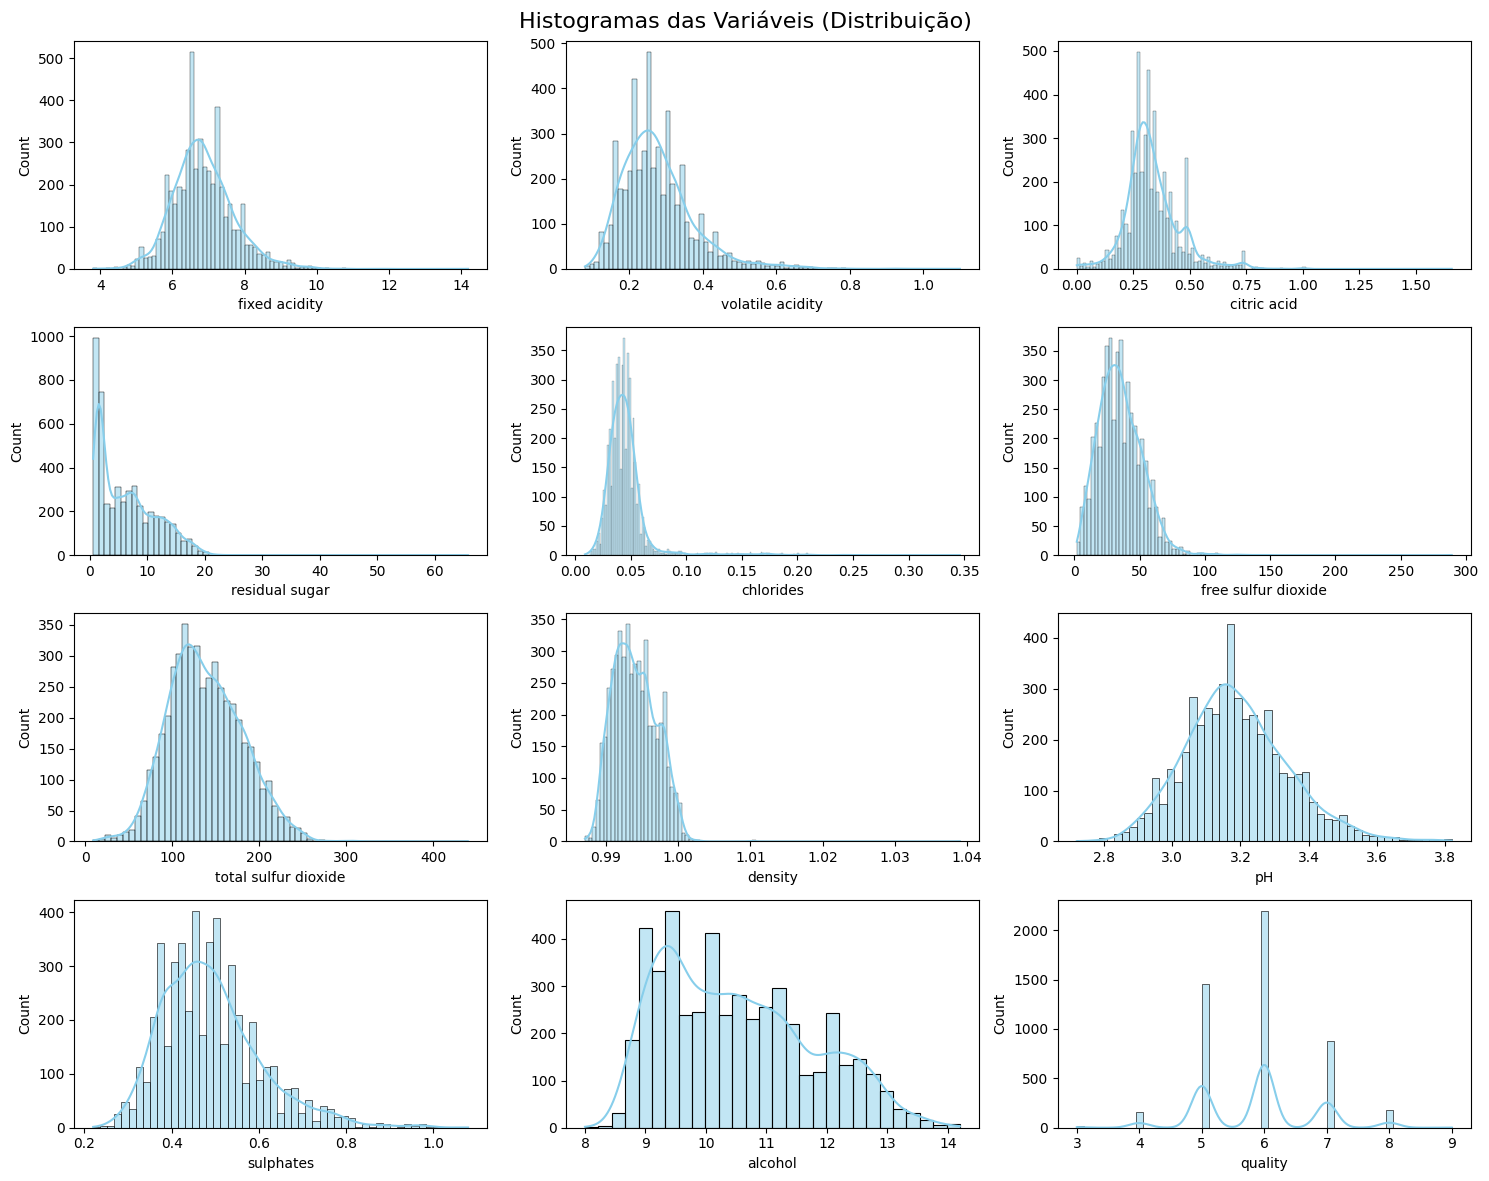

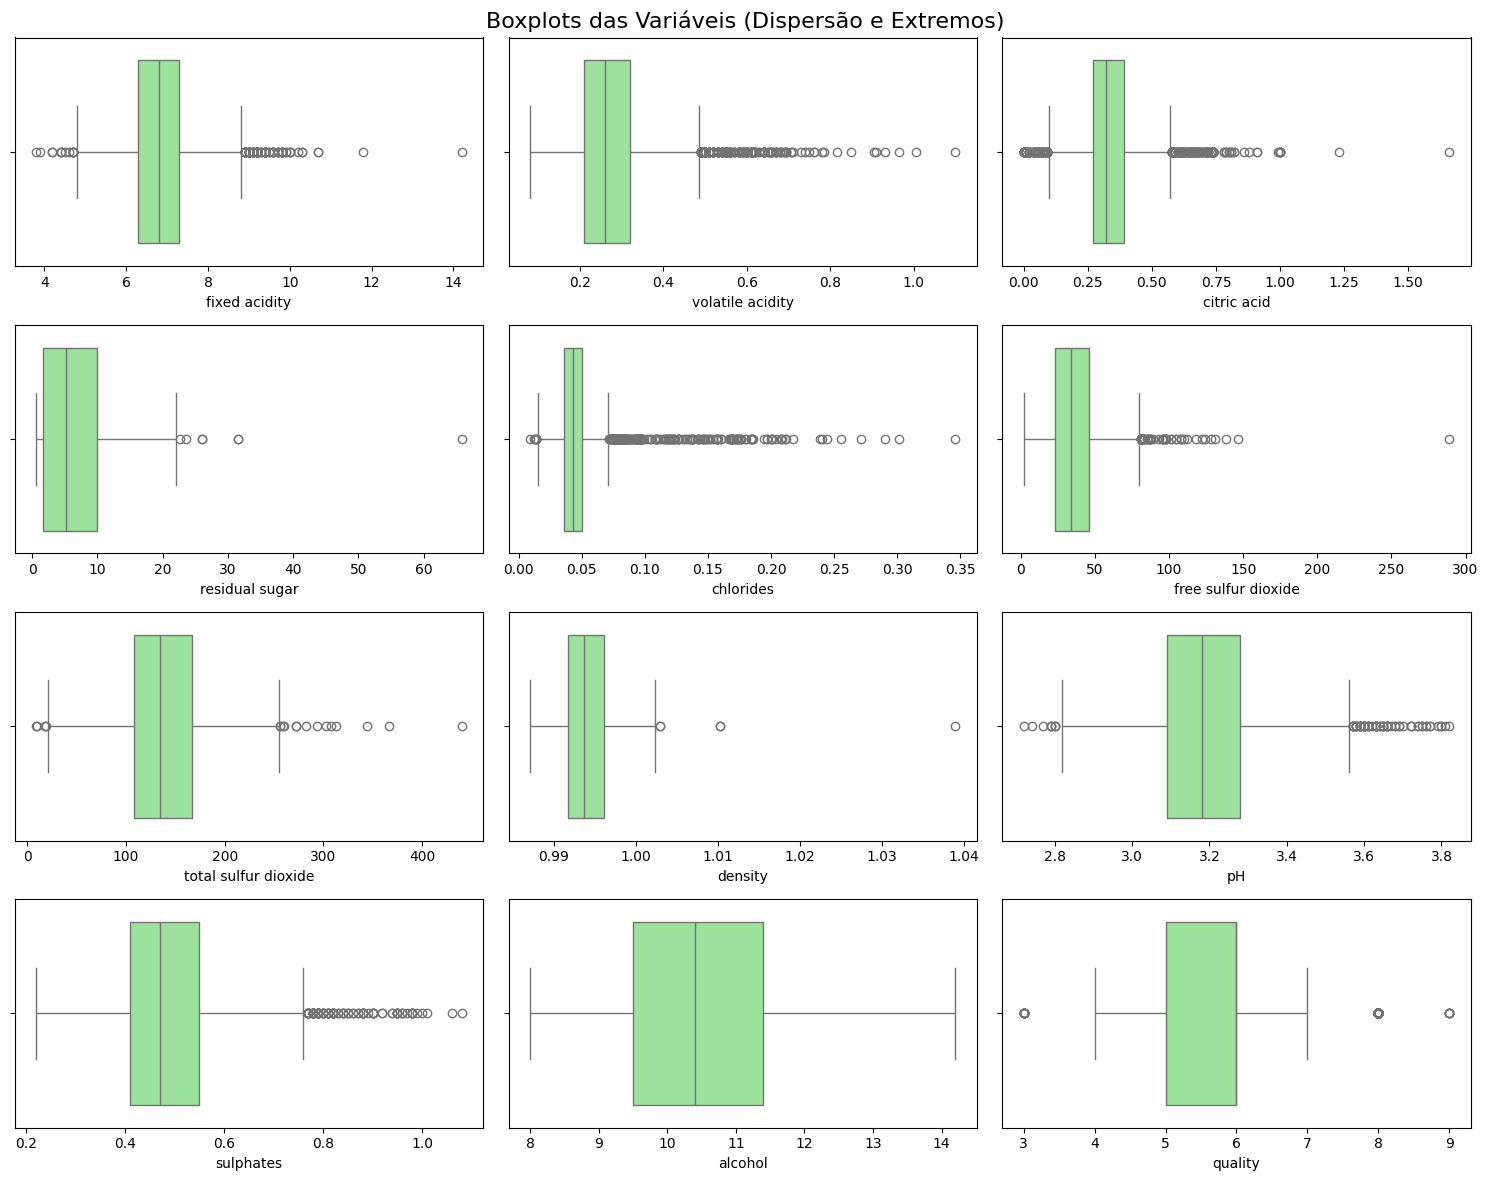

In [8]:
# 9. Gerar histogramas
fig, axes = plt.subplots(4, 3, figsize=(15, 12))
fig.suptitle('Histogramas das Variáveis (Distribuição)', fontsize=16)
for i, col in enumerate(df.columns):
    sns.histplot(df[col], kde=True, ax=axes[i//3, i%3], color='skyblue')
plt.tight_layout()
plt.show()

# 10. Gerar boxplots
fig, axes = plt.subplots(4, 3, figsize=(15, 12))
fig.suptitle('Boxplots das Variáveis (Dispersão e Extremos)', fontsize=16)
for i, col in enumerate(df.columns):
    sns.boxplot(x=df[col], ax=axes[i//3, i%3], color='lightgreen')
plt.tight_layout()
plt.show()

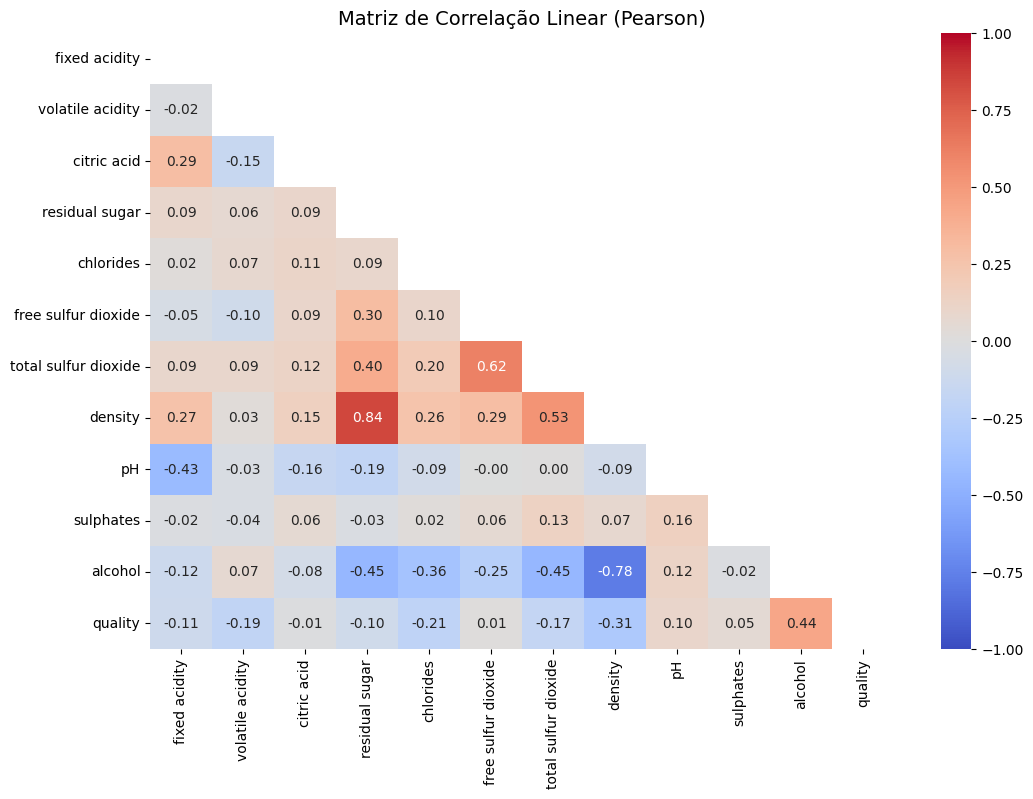

In [9]:
# 11. Gerar Matriz de Correlação
plt.figure(figsize=(12, 8))
corr = df.corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt=".2f", cmap='coolwarm', vmin=-1, vmax=1)
plt.title('Matriz de Correlação Linear (Pearson)', fontsize=14)
plt.show()

In [10]:
# 12. Destacar valores estatisticamente extremos usando Regra IQR (sem remover)
Q1 = df.quantile(0.25)
Q3 = df.quantile(0.75)
IQR = Q3 - Q1
extremos_estatisticos = ((df < (Q1 - 1.5 * IQR)) | (df > (Q3 + 1.5 * IQR))).sum()

print("--- Contagem de Observações 'Estatisticamente Extremas' (> 1.5 IQR) ---")
print(extremos_estatisticos[extremos_estatisticos > 0].sort_values(ascending=False))

--- Contagem de Observações 'Estatisticamente Extremas' (> 1.5 IQR) ---
citric acid             270
chlorides               208
quality                 200
volatile acidity        186
sulphates               124
fixed acidity           119
pH                       75
free sulfur dioxide      50
total sulfur dioxide     19
residual sugar            7
density                   5
dtype: int64
